### 1 Setup

#### Objective

1. Perform EDA
2. Train test split
3. Apply cross validation
4. Hyperparameter Tuning
5. Evaluate on testing set

#### Import Libraries

In [1]:
# General imports
import re

# Data manipulation libraries.
import numpy as np
import pandas as pd

# Data visualization libraries.
import matplotlib.pyplot as plt
import seaborn as sns

# Data modeling libraries.
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV, validation_curve
from sklearn.preprocessing import OrdinalEncoder, TargetEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

#### Configure Libraries

In [2]:
# Configure NumPy.
rng = np.random.default_rng(seed=42)
np.set_printoptions(linewidth=100)

# Configure Pandas.
pd.options.display.width = 100
pd.options.display.max_columns = None

# Configure Seaborn.
sns.set_style("whitegrid")
sns.set_palette("deep")

#### Helper Functions

In [3]:
def detect_outliers(df: pd.DataFrame, col_name: str):
    """
    Function to detect possible outliers outside IQR in the
    feature `col_name` and return mask to detect outliers.
    """
    # Get 25th percentile.
    Q1 = df[col_name].quantile(0.25)

    # Get 75th percentile.
    Q3 = df[col_name].quantile(0.75)

    # Get IQR value.
    IQR = Q3 - Q1

    # Calculate lower and upper bound.
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Mask to identify outliers in given DataFrame.
    out_mask = (df[col_name] < lower_bound) | (df[col_name] > upper_bound)

    df_row_count, _ = df.shape
    out_row_count, _ = df[out_mask].shape
    out_per = round((out_row_count / df_row_count) * 100, 2)

    return out_mask, out_row_count, out_per

In [4]:
remove_prefix = lambda params, prefix: {k.replace(prefix, ""): v for k, v in params}
delete_params = lambda params, grid, prefix: {
    p_name: values for p_name, values in grid.items() if p_name.replace(prefix, "") not in params
}

In [5]:
def get_param_name(full_param_name):
    """
    Function extract parameter name from prefix+parameter_name string.
    """
    pname_search = re.search(r"(?:.+)__(.+)", full_param_name, re.IGNORECASE)

    param_name = full_param_name
    if pname_search:
        param_name = pname_search.group(1)

    return param_name

In [6]:
def param_bv_tradeoff(estimator, X, y, param_name, param_range, cv, score):
    """
    Function to check Bias-Variance trade-off of a single parameter.
    """
    train_scores, test_scores = validation_curve(
        estimator,
        X,
        y,
        param_name=param_name,
        param_range=param_range,
        cv=cv,
        scoring=score,
        n_jobs=-1,
    )
    param_name = get_param_name(param_name)
    train_error = 1 - train_scores.mean(axis=1)
    test_error = 1 - test_scores.mean(axis=1)

    plt.figure(figsize=(6, 3))

    plt.plot(range(len(param_range)), train_error, marker="o", label="Train Error")
    plt.plot(range(len(param_range)), test_error, marker="o", label="Test Error")
    plt.xticks(range(len(param_range)), [str(x) for x in param_range])
    plt.xlabel(param_name)
    plt.ylabel("Error")
    plt.title(f"Bias-Variance Trade-off for parameter: '{param_name}'")
    plt.legend()

    plt.show()

#### Import Dataset

In [7]:
# https://www.kaggle.com/datasets/ziya07/employee-attrition-prediction-dataset
emp_df = pd.read_csv("data/employee_attrition_kaggle_dataset.csv")

display(emp_df.sample(5, random_state=rng))
row_count, col_count = emp_df.shape
print(f"Dataset contains {row_count} rows and {col_count} columns.")

,Employee_ID,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,Years_Since_Last_Promotion,Work_Life_Balance,Job_Satisfaction,Performance_Rating,Training_Hours_Last_Year,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition
771,772,42,Female,Single,IT,Manager,3,3060,29,28,12,9,3,1,1,95,No,2,58,5,1,2,1,29,2,No
438,439,22,Male,Divorced,Finance,Manager,5,14594,50,8,7,4,1,5,3,19,Yes,6,42,9,2,2,4,1,2,Yes
653,654,38,Female,Single,HR,Manager,1,6199,26,20,11,2,1,4,3,15,No,5,32,7,4,2,1,16,2,No
88,89,54,Female,Married,IT,Analyst,3,17389,40,12,7,5,1,3,4,78,No,1,46,6,4,2,4,21,2,No
433,434,54,Female,Single,Finance,Analyst,5,14664,53,28,4,9,1,4,1,8,Yes,7,55,0,1,4,4,16,3,Yes


Dataset contains 1000 rows and 26 columns.


### 2 Metadata Analysis

#### Metadata

In [8]:
emp_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   Employee_ID                    1000 non-null   int64
 1   Age                            1000 non-null   int64
 2   Gender                         1000 non-null   str  
 3   Marital_Status                 1000 non-null   str  
 4   Department                     1000 non-null   str  
 5   Job_Role                       1000 non-null   str  
 6   Job_Level                      1000 non-null   int64
 7   Monthly_Income                 1000 non-null   int64
 8   Hourly_Rate                    1000 non-null   int64
 9   Years_at_Company               1000 non-null   int64
 10  Years_in_Current_Role          1000 non-null   int64
 11  Years_Since_Last_Promotion     1000 non-null   int64
 12  Work_Life_Balance              1000 non-null   int64
 13  Job_Satisfaction              

#### Target Variable

In [9]:
pd.DataFrame(
    {
        "Count": (counts := emp_df["Attrition"].value_counts()),
        "Percentage": round(counts / counts.sum() * 100, 2),
    }
)

,Count,Percentage
Attrition,,
No,811,81.1
Yes,189,18.9


Dataset is highly imbalanced with:
- 81% Negative class-labels (No Attrition)
- 19% Positive class-labels (Attrition)

#### Cardinality

In [10]:
emp_df.nunique().sort_values(ascending=False)

Employee_ID                      1000
Monthly_Income                    971
Training_Hours_Last_Year          100
Hourly_Rate                        85
Distance_From_Home                 49
Age                                40
Average_Hours_Worked_Per_Week      30
Years_at_Company                   29
Absenteeism                        20
Years_in_Current_Role              14
Years_Since_Last_Promotion         10
Project_Count                       9
Department                          5
Job_Level                           5
Job_Satisfaction                    5
Relationship_with_Manager           4
Job_Role                            4
Performance_Rating                  4
Number_of_Companies_Worked          4
Job_Involvement                     4
Work_Life_Balance                   4
Work_Environment_Satisfaction       4
Marital_Status                      3
Gender                              2
Overtime                            2
Attrition                           2
dtype: int64

#### Correlation Matrix

In [11]:
# corr = emp_df.corr(numeric_only=True, method="spearman").round(2)

# plt.figure(figsize=(13, 9))
# sns.heatmap(corr, cmap="YlGnBu", linecolor="white", linewidth=0.5, vmin=-1, vmax=1, annot=True)
# plt.title("Correlation Matrix")
# plt.xticks(rotation=90)

# plt.show()

#### Drop unwanted columns

In [12]:
emp_df.drop(columns=["Employee_ID"], inplace=True)

### 3 Bi-variate Analysis

#### Attrition vs Overtime

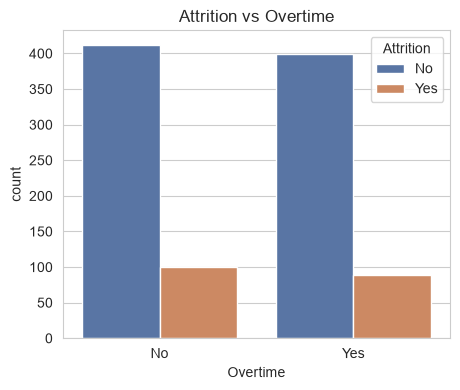

In [13]:
plt.figure(figsize=(5, 4))

sns.countplot(data=emp_df, x="Overtime", hue="Attrition")
plt.title("Attrition vs Overtime")

plt.show()

#### Attrition vs Gender

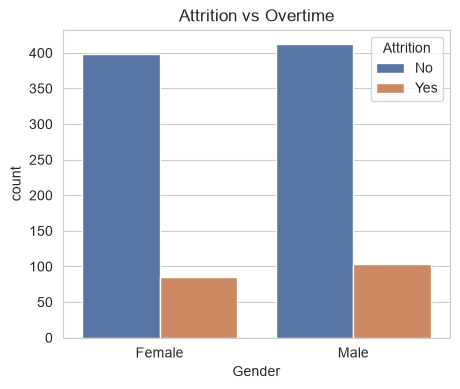

In [14]:
plt.figure(figsize=(5, 4))

sns.countplot(data=emp_df, x="Gender", hue="Attrition")
plt.title("Attrition vs Overtime")

plt.show()

#### Attrition vs Marital_Status

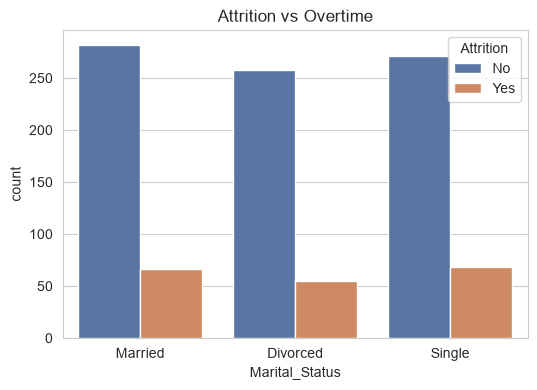

In [15]:
plt.figure(figsize=(6, 4))

sns.countplot(data=emp_df, x="Marital_Status", hue="Attrition")
plt.title("Attrition vs Overtime")

plt.show()

#### Attrition vs Department

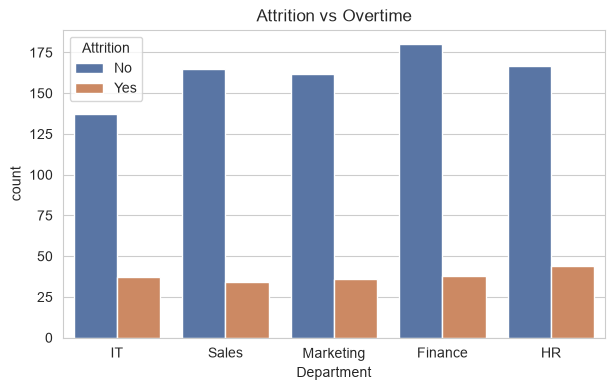

In [16]:
plt.figure(figsize=(7, 4))

sns.countplot(data=emp_df, x="Department", hue="Attrition")
plt.title("Attrition vs Overtime")

plt.show()

#### Attrition vs Job_Role

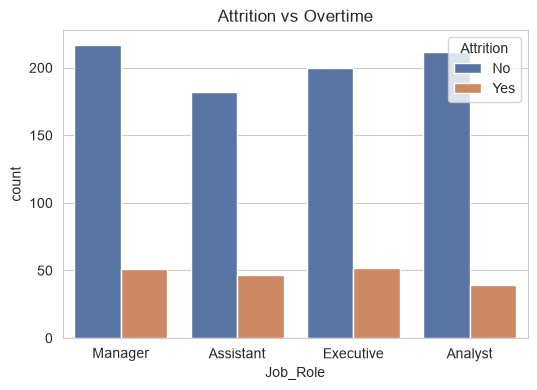

In [17]:
plt.figure(figsize=(6, 4))

sns.countplot(data=emp_df, x="Job_Role", hue="Attrition")
plt.title("Attrition vs Overtime")

plt.show()

### 4 Multi-variate Analysis

#### Attrition b/w Age & Average weekly hours

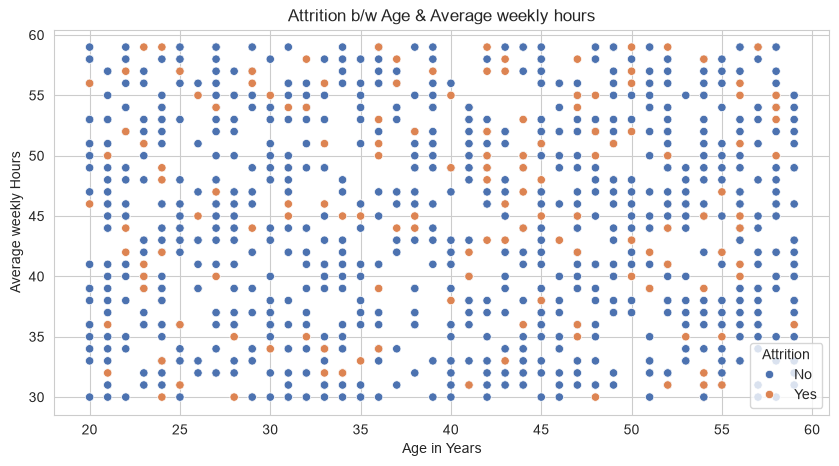

In [18]:
plt.figure(figsize=(10, 5))

sns.scatterplot(data=emp_df, x="Age", y="Average_Hours_Worked_Per_Week", hue="Attrition")
plt.title("Attrition b/w Age & Average weekly hours")
plt.xlabel("Age in Years")
plt.ylabel("Average weekly Hours")

plt.show()

#### Attrition b/w Training Hours & Average weekly hours

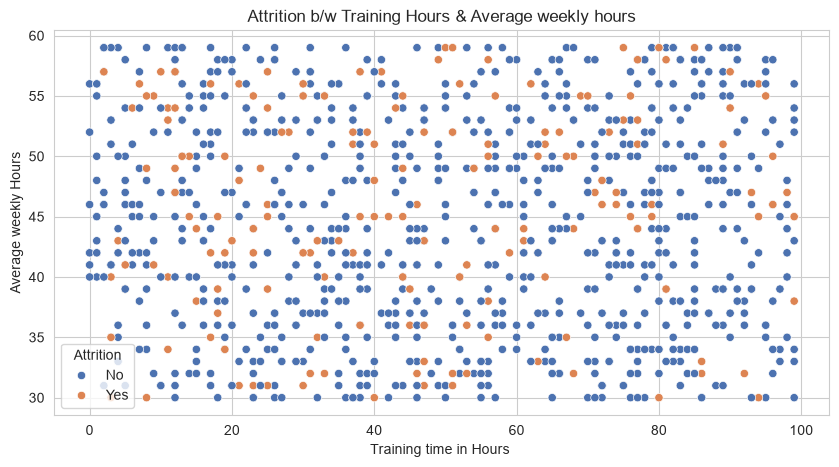

In [19]:
plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=emp_df, x="Training_Hours_Last_Year", y="Average_Hours_Worked_Per_Week", hue="Attrition"
)
plt.title("Attrition b/w Training Hours & Average weekly hours")
plt.xlabel("Training time in Hours ")
plt.ylabel("Average weekly Hours")

plt.show()

### 6 Outlier Treatment

#### Detect Outliers

In [20]:
print("Number of rows outside of IQR for each feature:\n")

for _, f_name in enumerate(emp_df.select_dtypes(include="number").columns):
    _, out_row_count, out_per = detect_outliers(emp_df, f_name)
    print(f"Feature `{f_name}`: {out_row_count} rows ({out_per}% of data)")

Number of rows outside of IQR for each feature:

Feature `Age`: 0 rows (0.0% of data)
Feature `Job_Level`: 0 rows (0.0% of data)
Feature `Monthly_Income`: 0 rows (0.0% of data)
Feature `Hourly_Rate`: 0 rows (0.0% of data)
Feature `Years_at_Company`: 0 rows (0.0% of data)
Feature `Years_in_Current_Role`: 0 rows (0.0% of data)
Feature `Years_Since_Last_Promotion`: 0 rows (0.0% of data)
Feature `Work_Life_Balance`: 0 rows (0.0% of data)
Feature `Job_Satisfaction`: 0 rows (0.0% of data)
Feature `Performance_Rating`: 0 rows (0.0% of data)
Feature `Training_Hours_Last_Year`: 0 rows (0.0% of data)
Feature `Project_Count`: 0 rows (0.0% of data)
Feature `Average_Hours_Worked_Per_Week`: 0 rows (0.0% of data)
Feature `Absenteeism`: 0 rows (0.0% of data)
Feature `Work_Environment_Satisfaction`: 0 rows (0.0% of data)
Feature `Relationship_with_Manager`: 0 rows (0.0% of data)
Feature `Job_Involvement`: 0 rows (0.0% of data)
Feature `Distance_From_Home`: 0 rows (0.0% of data)
Feature `Number_of_Compa

Dataset has no outliers!

### 7 Training Setup

#### Target Variable Encoding

In [21]:
emp_df["Attrition"].value_counts()

Attrition
No     811
Yes    189
Name: count, dtype: int64

In [22]:
emp_df["Attrition"] = emp_df["Attrition"].map(
    {
        "Yes": 1,
        "No": 0,
    }
)
emp_df["Attrition"].value_counts()

Attrition
0    811
1    189
Name: count, dtype: int64

#### Train test split

In [24]:
X = emp_df[emp_df.columns.difference(["Attrition"])]
y = emp_df["Attrition"]

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((700, 24), (300, 24), (700,), (300,))

In [26]:
pd.DataFrame(
    {
        "Count": (counts := y_train.value_counts()),
        "Percentage": round(counts / counts.sum() * 100, 2),
    }
)

,Count,Percentage
Attrition,,
0,568,81.14
1,132,18.86


In [27]:
pd.DataFrame(
    {
        "Count": (counts := y_test.value_counts()),
        "Percentage": round(counts / counts.sum() * 100, 2),
    }
)

,Count,Percentage
Attrition,,
0,243,81.0
1,57,19.0


#### Define Feature Transformer

In [28]:
# Print info of non-numeric columns only.
mask = X_train.columns.difference(X_train.select_dtypes("number").columns)
X_train[mask].info()

<class 'pandas.DataFrame'>
Index: 700 entries, 677 to 557
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Department      700 non-null    str  
 1   Gender          700 non-null    str  
 2   Job_Role        700 non-null    str  
 3   Marital_Status  700 non-null    str  
 4   Overtime        700 non-null    str  
dtypes: str(5)
memory usage: 32.8 KB


##### Feature Encoding

Encoding strategy:

```
Department     | Ordinal
Gender         | TargetEncoding  | Avoid OneHot for Tree based models
Job_Role       | Ordinal
Marital_Status | TargetEncoding
Overtime       | Ordinal
```

In [29]:
# Encoding order for: Department.
dpt_en = ["Finance", "HR", "IT", "Marketing", "Sales"]

# Encoding order for: Gender.
gen_en = ["Female", "Male"]

# Encoding order for: Job Role.
job_role_en = ["Analyst", "Assistant", "Manager", "Executive"]

# Encoding order for: Marital_Status.
ms_en = ["Divorced", "Married", "Single"]

# Encoding order for: Overtime.
ot_en = ["No", "Yes"]

preprocessor = ColumnTransformer(
    transformers=[
        ("en_Department", OrdinalEncoder(categories=[dpt_en], dtype=np.int8), ["Department"]),
        ("en_Gender", OrdinalEncoder(categories=[gen_en], dtype=np.int8), ["Gender"]),
        ("en_Job_Role", OrdinalEncoder(categories=[job_role_en], dtype=np.int8), ["Job_Role"]),
        ("en_Marital_Status", OrdinalEncoder(categories=[ms_en], dtype=np.int8), ["Marital_Status"]),
        ("en_Overtime", OrdinalEncoder(categories=[ot_en], dtype=np.int8), ["Overtime"]),
    ],
    remainder="passthrough",  # Keeps all other columns unchanged.
    verbose_feature_names_out=False,
)
preprocessor.set_output(transform="pandas")

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('en_Department', ...), ('en_Gender', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_name}__{transformer_name}""``. See :meth:`str.format` method from the standard library for more info... versionadded:: 1.0.. versionchanged:: 1.6 `verbose_feature_names_out` can be a callable or a string to be formatted.",False
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for f

### 8 Training

#### Base Model

In [30]:
base_pipeline = Pipeline(
    steps=[
        ("preprocessing", clone(preprocessor)),
        ("base_model", RandomForestClassifier(class_weight="balanced", n_jobs=-1, random_state=42)),
    ]
)

base_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('base_model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](24,)","['Absenteeism','Age','Average_Hours_Worked_Per_Week',...,'Years_Since_Last_Promotion', 'Years_at_Company','Years_in_Current_Role']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,24
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('en_Department', ...), ('en_Gender', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumn

#### Training Accuracy

In [31]:
tr_acc = base_pipeline.score(X_train, y_train)
print("Training accuracy:", round(tr_acc * 100, 2))

Training accuracy: 100.0


#### Testing Accuracy

In [32]:
ts_acc = base_pipeline.score(X_test, y_test)
print("Testing accuracy:", round(ts_acc * 100, 2))

Testing accuracy: 80.67


##### Observations

- Training accuracy is 100% but testing accuracy is 81%.
- Base model is overfitting

### 9 Hyperparameter Tuning

#### K-Fold Cross validation

In [33]:
cv_pipeline = Pipeline(
    steps=[
        ("preprocessing", clone(preprocessor)),
        ("cv_model", RandomForestClassifier(class_weight="balanced", n_jobs=-1, random_state=42)),
    ]
)

In [34]:
prefix = "cv_model__"

param_grid = {
    prefix + "n_estimators": [5, 10, 15, 20, 25],
    prefix + "max_depth": [1, 2, 3, 4, 5, 5, 6, 7],
    prefix + "max_features": [3, 5, 10, 15, 20],
    prefix + "min_samples_split": [5, 10, 15, 20, 25, 30],
    prefix + "min_samples_leaf": [2, 4, 6, 8, 10],
}

cv = 3

#### Bias-Variance Trade off

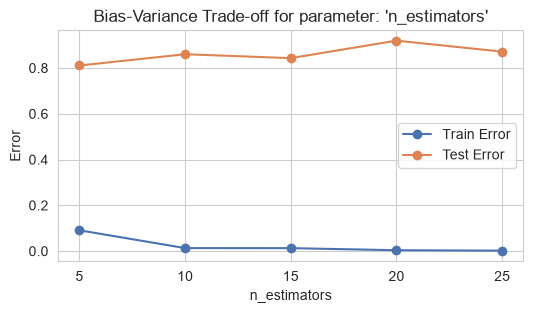

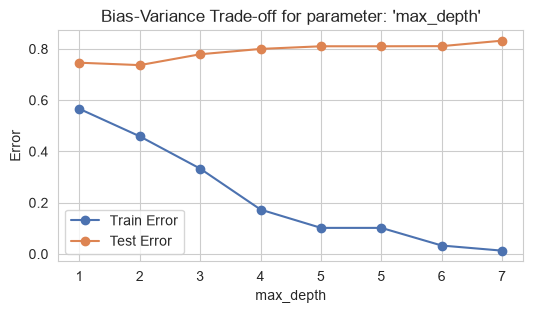

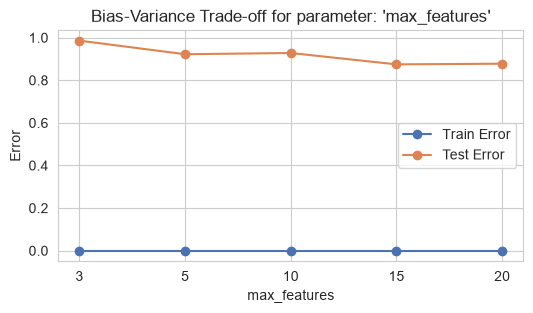

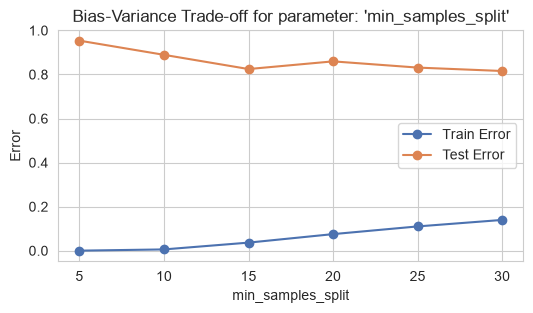

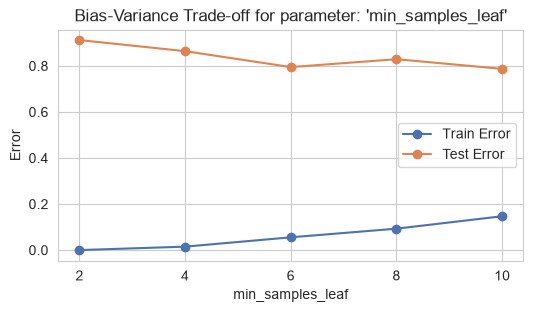

In [35]:
for param_name, param_range in param_grid.items():
    param_bv_tradeoff(cv_pipeline, X_train, y_train, param_name, param_range, cv, "f1")

##### Observations

- `max_features` has no impact in Bias-Variance trade off hence delete that parameter from param grid.

#### Grid Search for Best Parameters

In [36]:
final_param_grid = delete_params(params=["max_features"], grid=param_grid, prefix=prefix)
final_param_grid

{'cv_model__n_estimators': [5, 10, 15, 20, 25],
 'cv_model__max_depth': [1, 2, 3, 4, 5, 5, 6, 7],
 'cv_model__min_samples_split': [5, 10, 15, 20, 25, 30],
 'cv_model__min_samples_leaf': [2, 4, 6, 8, 10]}

In [37]:
gs_cv = GridSearchCV(
    estimator=cv_pipeline,
    param_grid=final_param_grid,
    cv=cv,
    scoring="f1",
    return_train_score=True,
    n_jobs=-1,
    verbose=1,
)

gs_cv.fit(X_train, y_train)

print(f"Best Parameters: {gs_cv.best_params_}")
print(f"Best Cross-Validation Score: {gs_cv.best_score_:.4f}")

Fitting 3 folds for each of 1200 candidates, totalling 3600 fits
Best Parameters: {'cv_model__max_depth': 5, 'cv_model__min_samples_leaf': 4, 'cv_model__min_samples_split': 30, 'cv_model__n_estimators': 5}
Best Cross-Validation Score: 0.3122


#### Feature Importance

In [38]:
best_model = gs_cv.best_estimator_.named_steps["cv_model"]

fi_df = pd.DataFrame(
    {
        "Feature": best_model.feature_names_in_,
        "Importance": best_model.feature_importances_.round(2),
    }
).sort_values(by="Importance", ascending=False, ignore_index=True)
fi_df.head(5)

,Feature,Importance
0,Monthly_Income,0.09
1,Hourly_Rate,0.09
2,Project_Count,0.08
3,Job_Level,0.08
4,Absenteeism,0.07


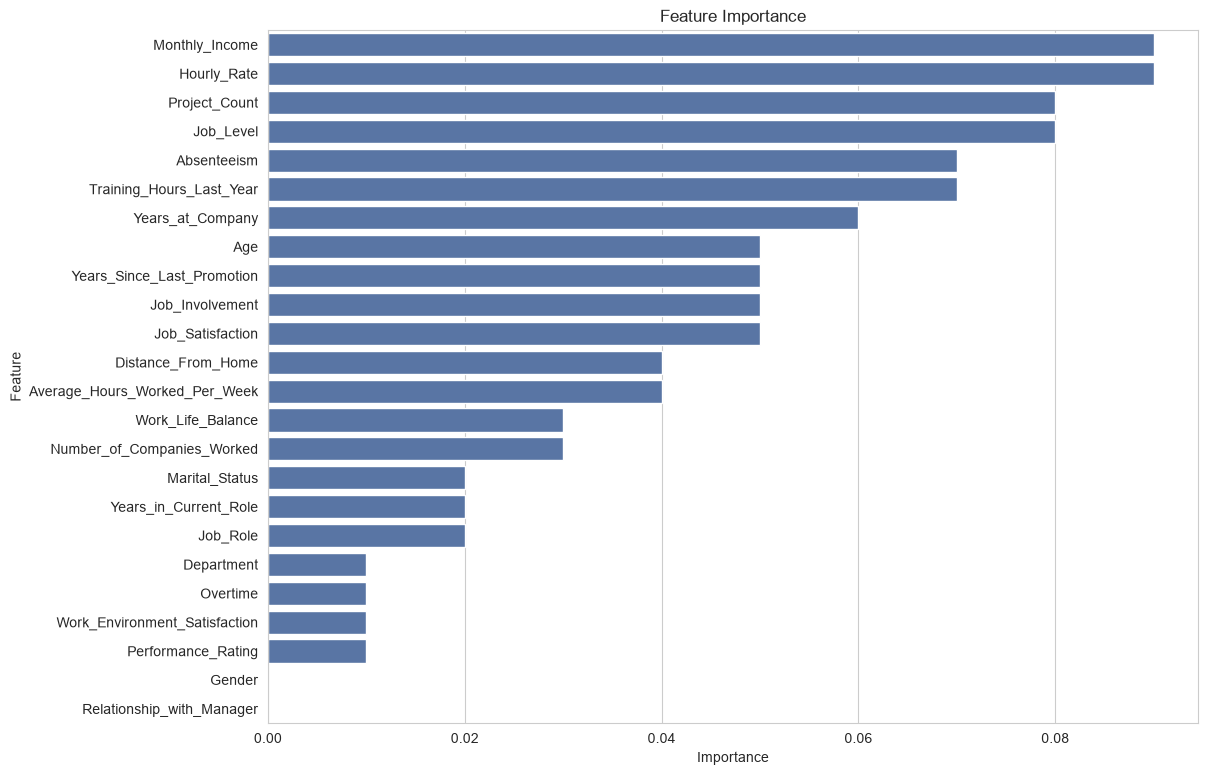

In [39]:
plt.figure(figsize=(12, 9))

sns.barplot(data=fi_df, x="Importance", y="Feature")
plt.title("Feature Importance")

plt.show()

### 10 Model Evaluation

#### Final Model

In [40]:
# Init a finalized Random Forest model.
final_model = RandomForestClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
    **remove_prefix(gs_cv.best_params_.items(), prefix),
)

final_pipeline = Pipeline(
    steps=[
        ("preprocessing", clone(preprocessor)),
        ("final_model", final_model),
    ]
)

final_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('final_model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](24,)","['Absenteeism','Age','Average_Hours_Worked_Per_Week',...,'Years_Since_Last_Promotion', 'Years_at_Company','Years_in_Current_Role']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,24
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('en_Department', ...), ('en_Gender', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolum

#### Training Accuracy

In [41]:
tr_acc = final_pipeline.score(X_train, y_train)
print("Training accuracy:", round(tr_acc * 100, 2))

Training accuracy: 69.14


#### Testing Accuracy

In [42]:
ts_acc = final_pipeline.score(X_test, y_test)
print("Testing accuracy:", round(ts_acc * 100, 2))

Testing accuracy: 55.33
